In [6]:
library(repr)
library(tidyverse)

In [7]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
options(bitmapType = 'cairo')
library(showtext)
font_add_google("Lato", "lato")
font_add_google(name = "Roboto", family = "roboto")
showtext_opts(dpi = 300)
showtext_auto()

In [8]:
df <- read_csv("median_io_group_gaze.csv")
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


May not be necessary for the manuscript(?)

MBH thinks that it does not help one understand what's the issue of it. He has a very solid point.
From my point of view, it's used to 

Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_density()`).”


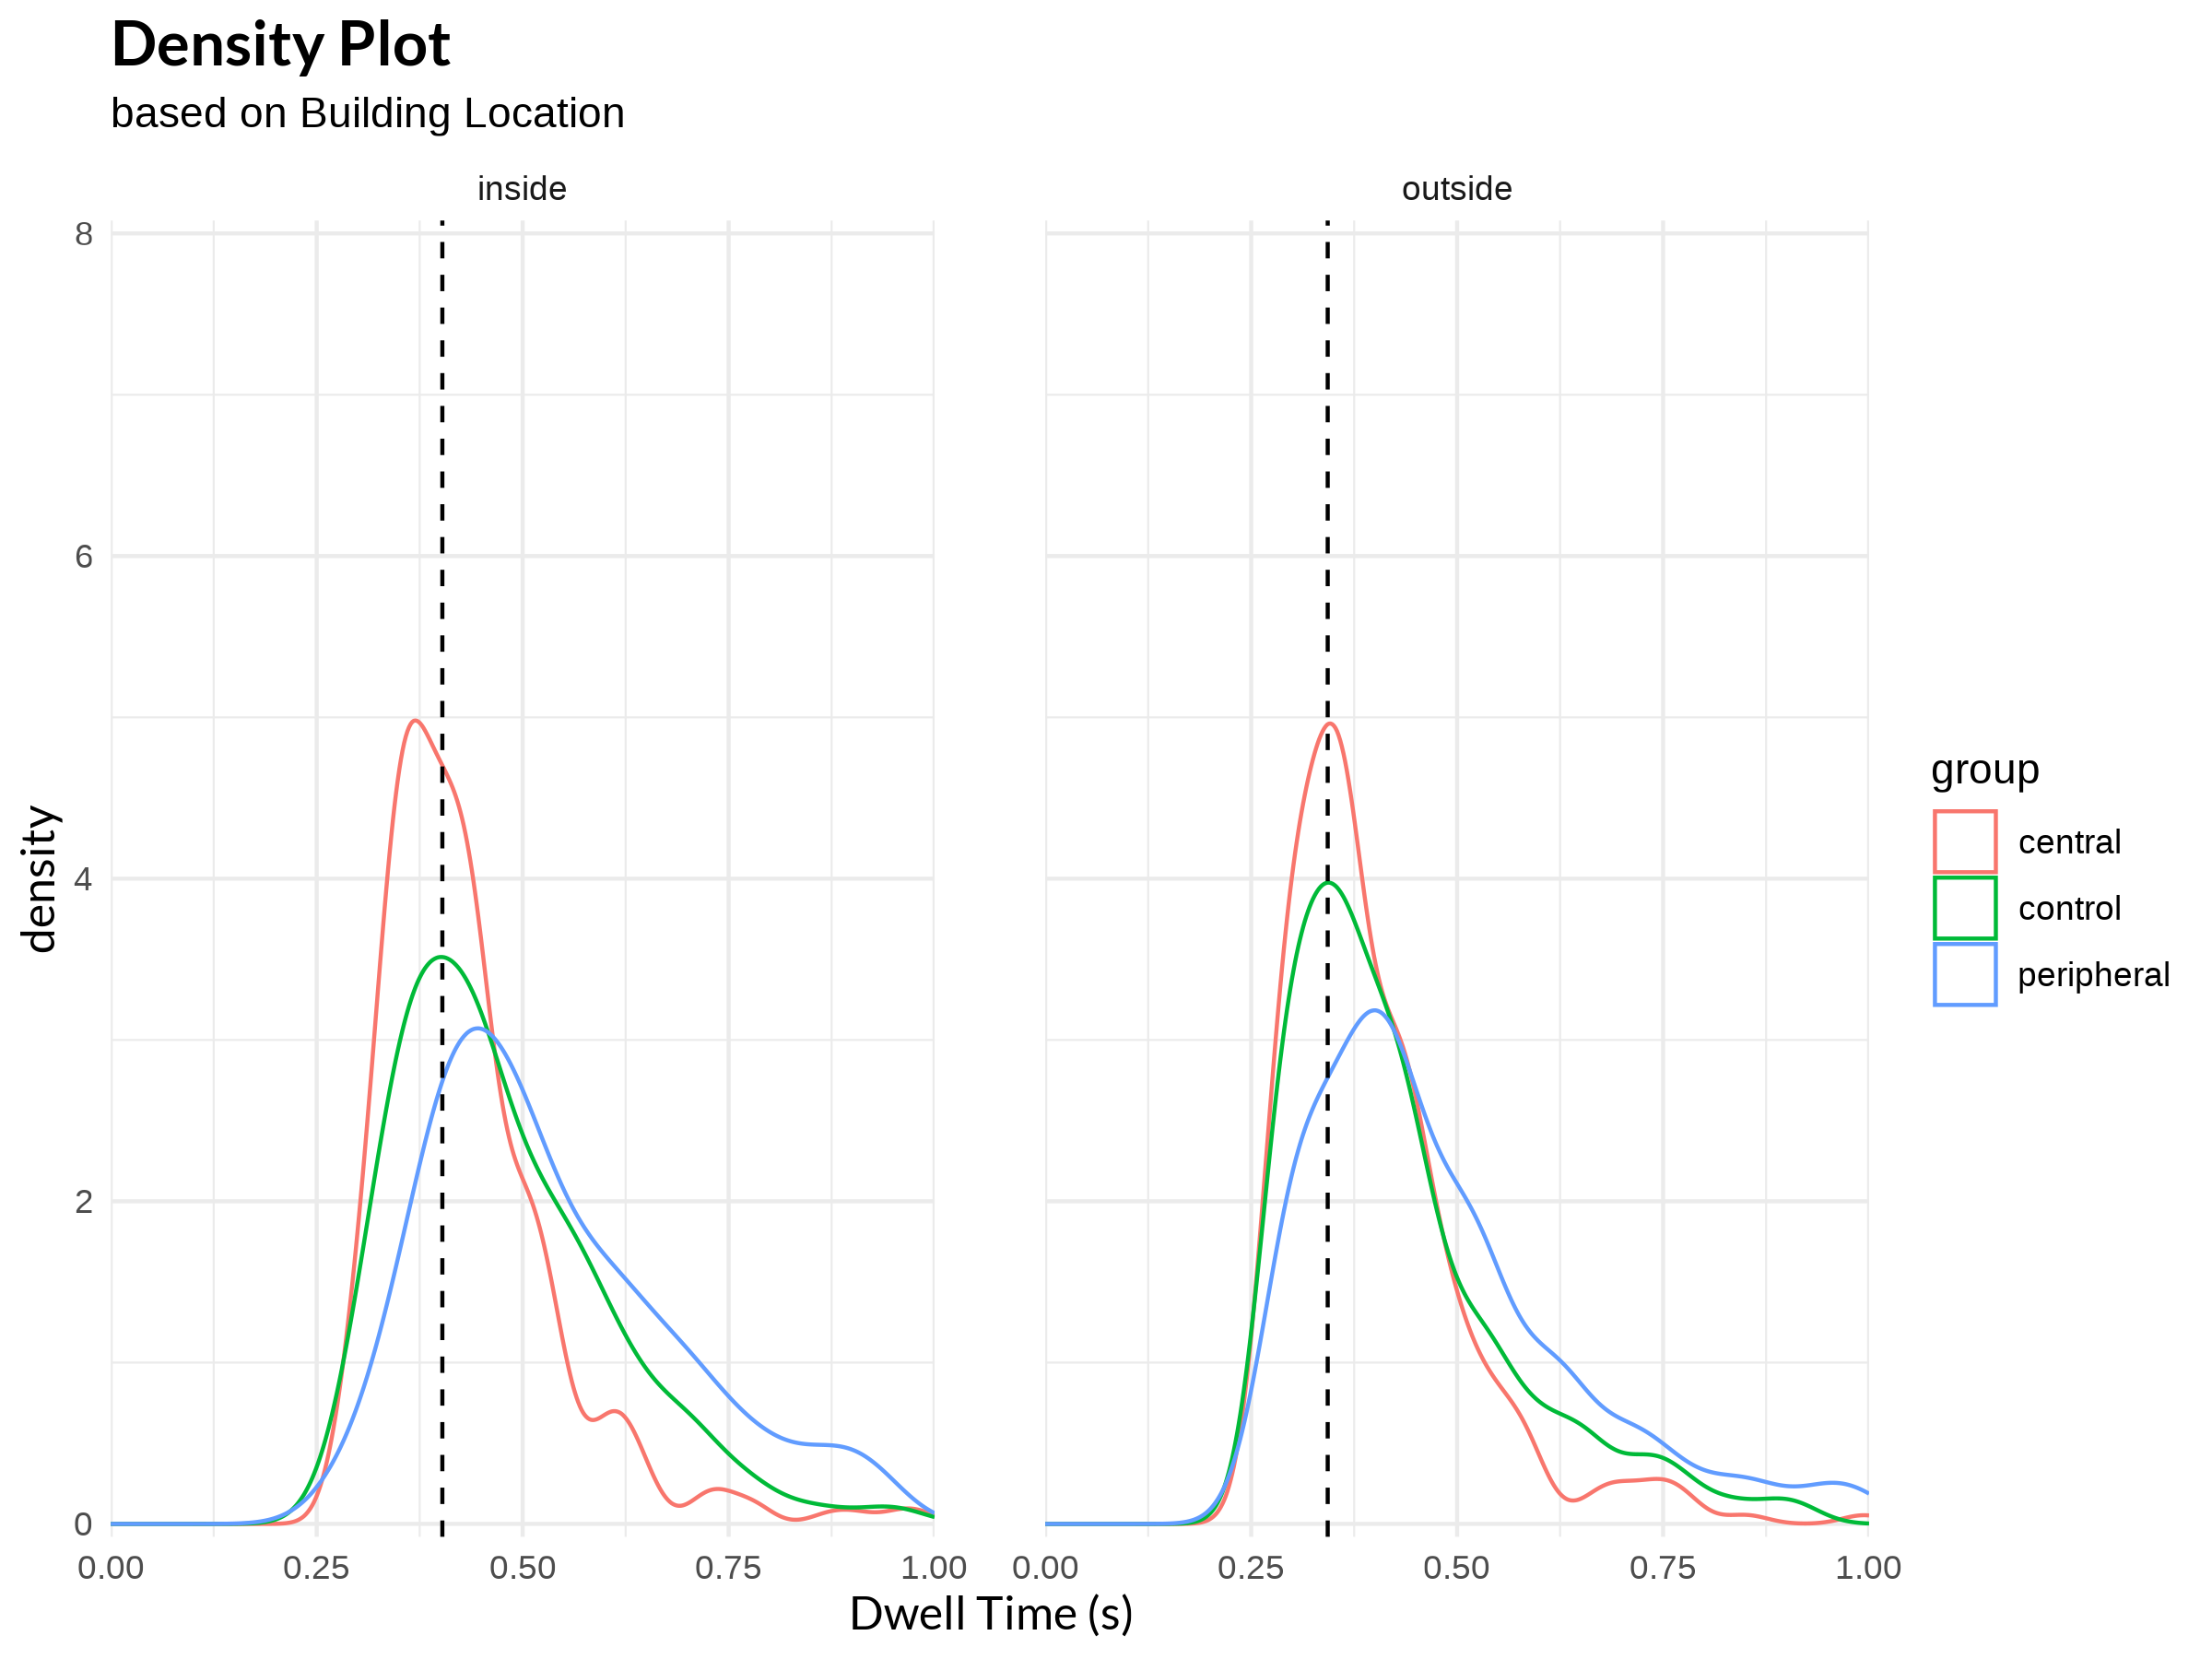

In [11]:
mode_value_inside <- df %>%
  filter(group == "control" & building_location == "inside") %>%
  pull(median_clusterDuration) %>%
  density() %>%
  {.$x[which.max(.$y)]}
mode_value_outside <- df %>%
  filter(group == "control" & building_location == "outside") %>%
  pull(median_clusterDuration) %>%
  density() %>%
  {.$x[which.max(.$y)]}

mode_values <- tibble(building_location = c("inside", "outside"), x = c(mode_value_inside , mode_value_outside))

fig <- df |>
  ggplot(aes(x = median_clusterDuration, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  scale_x_continuous(limits = c(0, 1), expand = c(0,0)) +
  scale_y_continuous(limits = c(0, 8), expand = c(0.01, 0)) +
  geom_vline(aes(xintercept = x), linetype = "dashed", data = mode_values) +
  facet_wrap(~ building_location) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot",
      subtitle = "based on Building Location",
       x = "Dwell Time (s)",
       y = "density") +
  theme(
    plot.title = element_text(family = "lato", size = 16, face = "bold"),
    axis.title.x = element_text(family = "lato", size = 12),
    axis.title.y = element_text(family = "lato", size = 12),
    panel.spacing = unit(2, "lines")
   )
fig

In [12]:
library(lme4)
library(emmeans)
library(performance)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [13]:
# Fit a generalized linear mixed model (GLMM) using glmer
# Assuming a dataset 'data' with a binary response variable 'y', 
# a fixed effect 'x', and a random effect 'group'
model <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, Gamma(link = "inverse"))
# model0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1| hitObjectColliderName), data = df, Gamma(link = "inverse"))

In [15]:
df_summary <- df %>%
    group_by(group) %>%
    summarise(
        med_med = mean(median_clusterDuration),
    ) %>%
    ungroup()

df_summary

group,med_med
<chr>,<dbl>
central,0.4317396
control,0.4713076
peripheral,0.5561940


In [20]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_eff <- emmeans(model, ~ group)
eff_size(emm_eff, sigma = sigma(model)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)


 contrast             effect.size    SE  df asymp.LCL asymp.UCL
 central - control          0.359 0.180 Inf    0.0072     0.711
 central - peripheral       0.934 0.182 Inf    0.5771     1.291
 control - peripheral       0.575 0.183 Inf    0.2163     0.933

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.5215 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,central,0.4004916,0.01403735,Inf,0.3729789,0.4280043
2,control,0.4331715,0.01687316,Inf,0.4001007,0.4662423
3,peripheral,0.4982905,0.02314886,Inf,0.4529195,0.5436614


 contrast             estimate     SE  df z.ratio p.value
 central - control     -0.0327 0.0166 Inf  -1.972  0.1191
 central - peripheral  -0.0978 0.0210 Inf  -4.646  <.0001
 control - peripheral  -0.0651 0.0216 Inf  -3.013  0.0073

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

In [21]:
# For building location only
# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(model, ~ building_location)
eff_size(emm_eff, sigma = sigma(model)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)


 contrast         effect.size    SE  df asymp.LCL asymp.UCL
 outside - inside        0.68 0.185 Inf     0.317      1.04

Results are averaged over the levels of: group 
sigma used for effect sizes: 0.5215 
Confidence level used: 0.95 

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4089795,0.01269408,Inf,0.3840996,0.4338594
2,inside,0.4789896,0.02165684,Inf,0.4365429,0.5214362


 contrast         estimate     SE  df z.ratio p.value
 outside - inside    -0.07 0.0207 Inf  -3.376  0.0007

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

In [13]:
r2_nakagawa(model, by_group = TRUE)
r2_nakagawa(model)
icc(model)
icc(model, by_group = TRUE)

,Level,R2
,<chr>,<dbl>
,Level 1,0.01841683
PID,PID,0.53912946
hitObjectColliderName,hitObjectColliderName,0.12725534


# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

ICC_adjusted,ICC_conditional,ICC_unadjusted
<dbl>,<dbl>,<dbl>
0.4123171,0.3162221,0.3162221


Group,ICC
<chr>,<dbl>
hitObjectColliderName,0.3498808
PID,0.0624363


In [16]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )

df_node |> head()


Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


clusterID,sampleNr,duration,building,PID,group,building_location,connections
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>
2,121,1.3477349,TaskBuilding_35,4003,peripheral,inside,17
7,35,0.3888457,Building_166,4003,peripheral,inside,12
9,39,0.4330869,Building_168,4003,peripheral,inside,11
10,33,0.3671408,TaskBuilding_42,4003,peripheral,inside,12
12,57,0.6329131,Building_166,4003,peripheral,inside,12
13,56,0.6199913,Building_166,4003,peripheral,inside,12


In [17]:
pid_order <- df_node |> arrange(group) |> distinct(PID) |> pull(PID)

In [19]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group',
'building_location'. You can override using the `.groups` argument.


In [20]:
# peripheral central control

group_df_node <- df_node |> group_by(group) |> group_split()

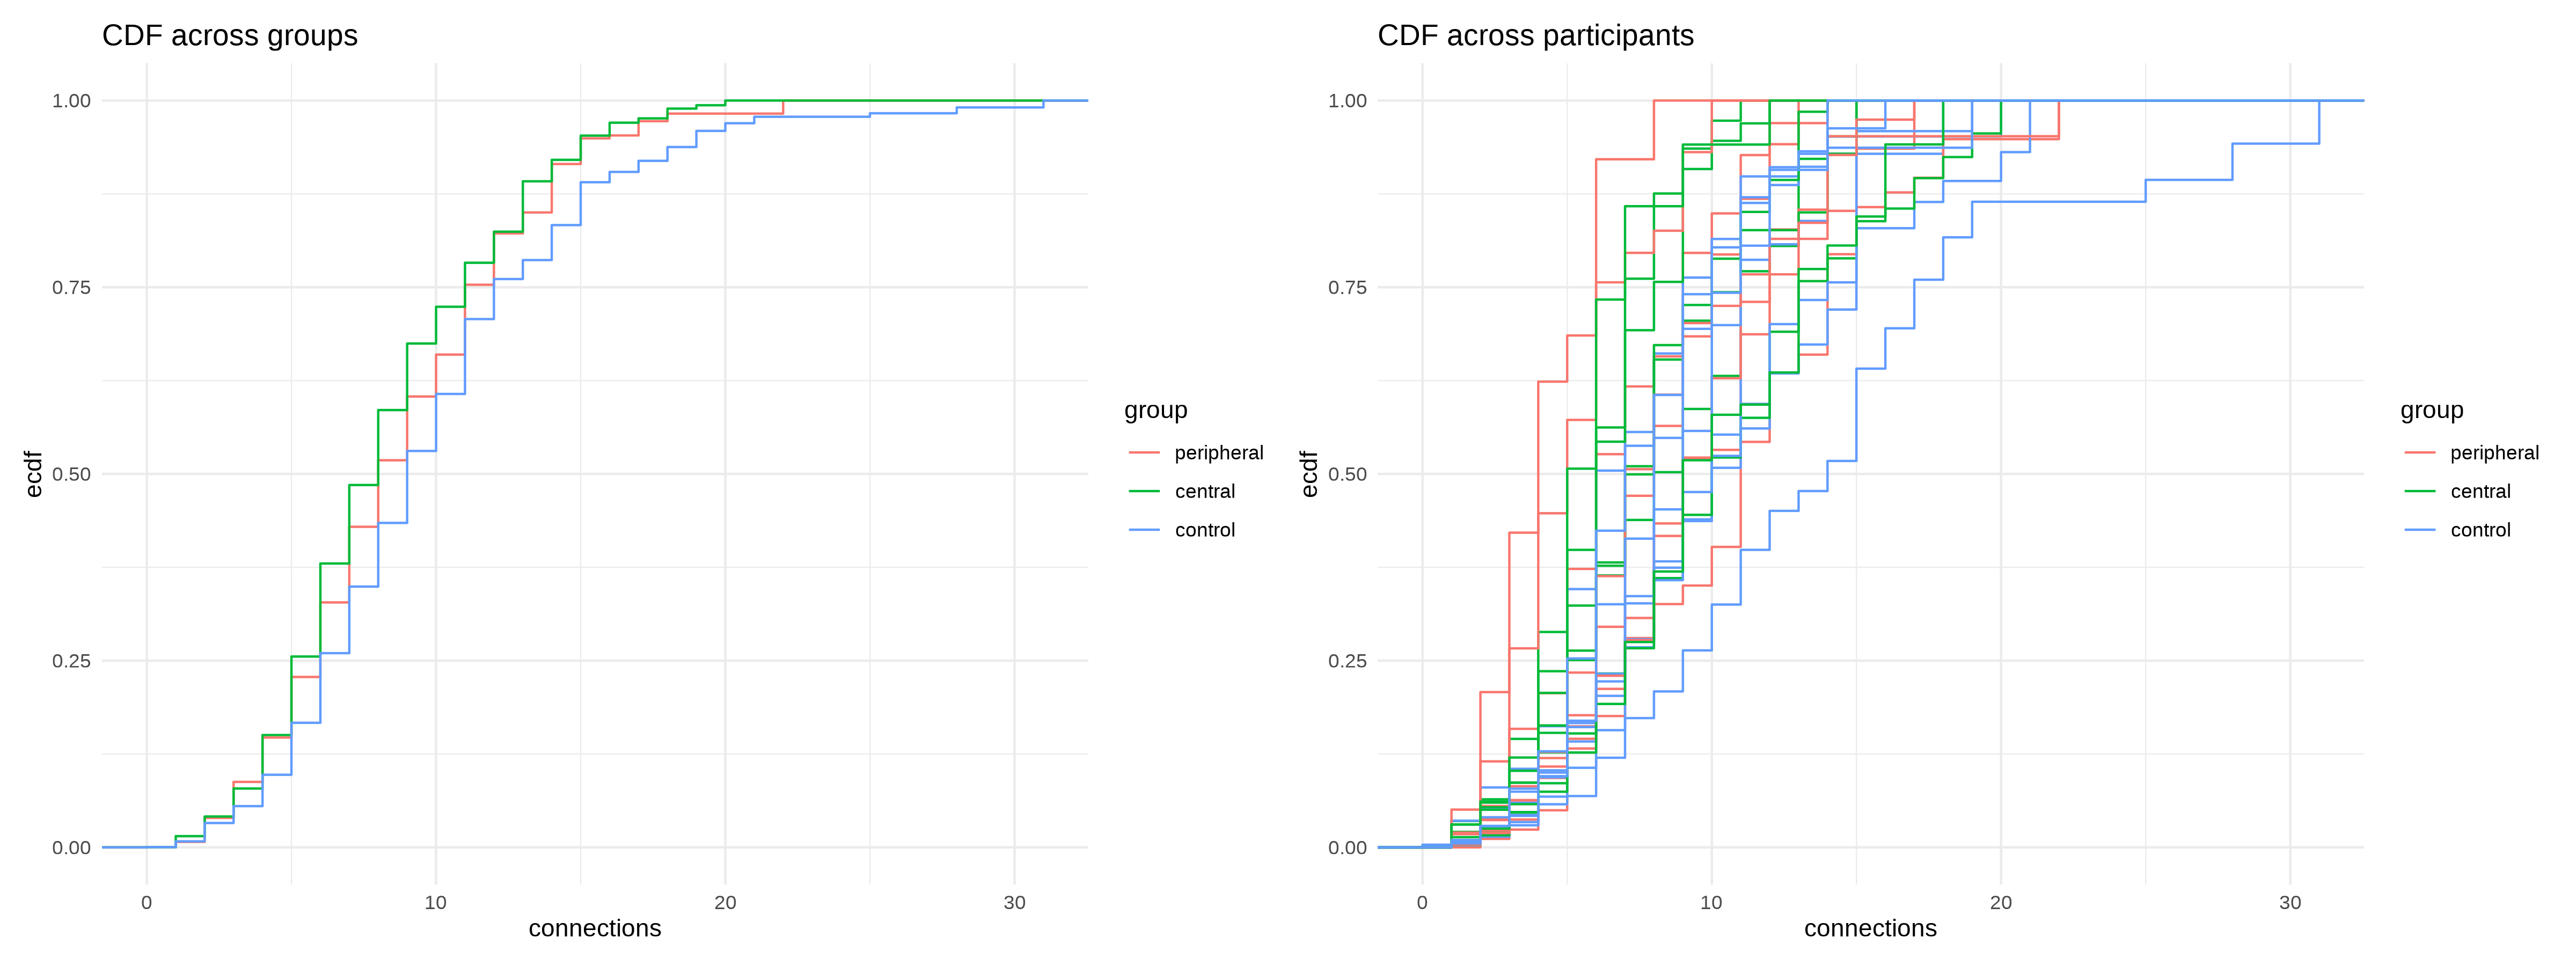

In [22]:
library(patchwork)
fig_group <- ggplot(df_node, aes(connections, group = group, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across groups") +
  theme_minimal()
fig_participants <- ggplot(df_node, aes(connections, group = PID, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across participants") + 
  theme_minimal()
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 300)
fig_group | fig_participants
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
ggsave("group_node_degree_ecdf.svg", fig_group | fig_participants, width = 16, height = 6, units = "in", dpi = 300)

In [23]:
plot_group_cdf_with_ribbon <- function(df, value_col, individual_col, group_col = NULL,
                                       probs = c(0.05, 0.95), x_points = 200) {
  # Create x grid
  x_grid <- df %>% pull({{ value_col }}) %>% range() %>%
    (\(rng) seq(rng[1], rng[2], length.out = x_points))()

  # Compute ECDFs
  ecdf_df <- df %>%
    nest(data = -c({{ group_col }}, {{ individual_col }})) %>%
    mutate(ecdf = map(data, ~ ecdf(pull(.x, {{ value_col }})))) %>%
    crossing(x = x_grid) %>%
    mutate(y = map2_dbl(ecdf, x, ~ .x(.y))) %>%
    select({{ group_col }}, {{ individual_col }}, x, y)

  # Summarize across individuals
  ecdf_summary <- ecdf_df %>%
    group_by({{ group_col }}, x) %>%
    summarize(
      ymin = quantile(y, probs[1]),
      ymax = quantile(y, probs[2]),
      ymed = median(y),
      .groups = "drop"
    )

  group_ecdf_df <- df %>%
      group_by({{ group_col }}) %>%
      summarize(data = list({{ value_col }}), .groups = "drop") %>%
      mutate(ecdf = map(data, ~ ecdf(.x))) %>%
      crossing(x = x_grid) %>%
      mutate(y = map2_dbl(ecdf, x, ~ .x(.y)))

  # Plot
  ggplot(ecdf_summary, aes(x = x, group = {{ group_col }}, fill = {{ group_col }}, color = {{ group_col }})) +
    geom_ribbon(aes(ymin = ymin, ymax = ymax), alpha = 0.3, color = NA) +
    geom_line(data = group_ecdf_df, aes(x = x, y = y, color = {{ group_col }}), size = 1) +
    theme_minimal() +
    labs(x = "node degree", y = "ECDF", title = "Group CDFs with Individual Variation",
         subtitle = paste0("Ribbon = ", probs[1]*100, "% to ", probs[2]*100, "% quantile of individuals")) +
    guides(fill = guide_legend(title = "Group"), color = guide_legend(title = "Group"))
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


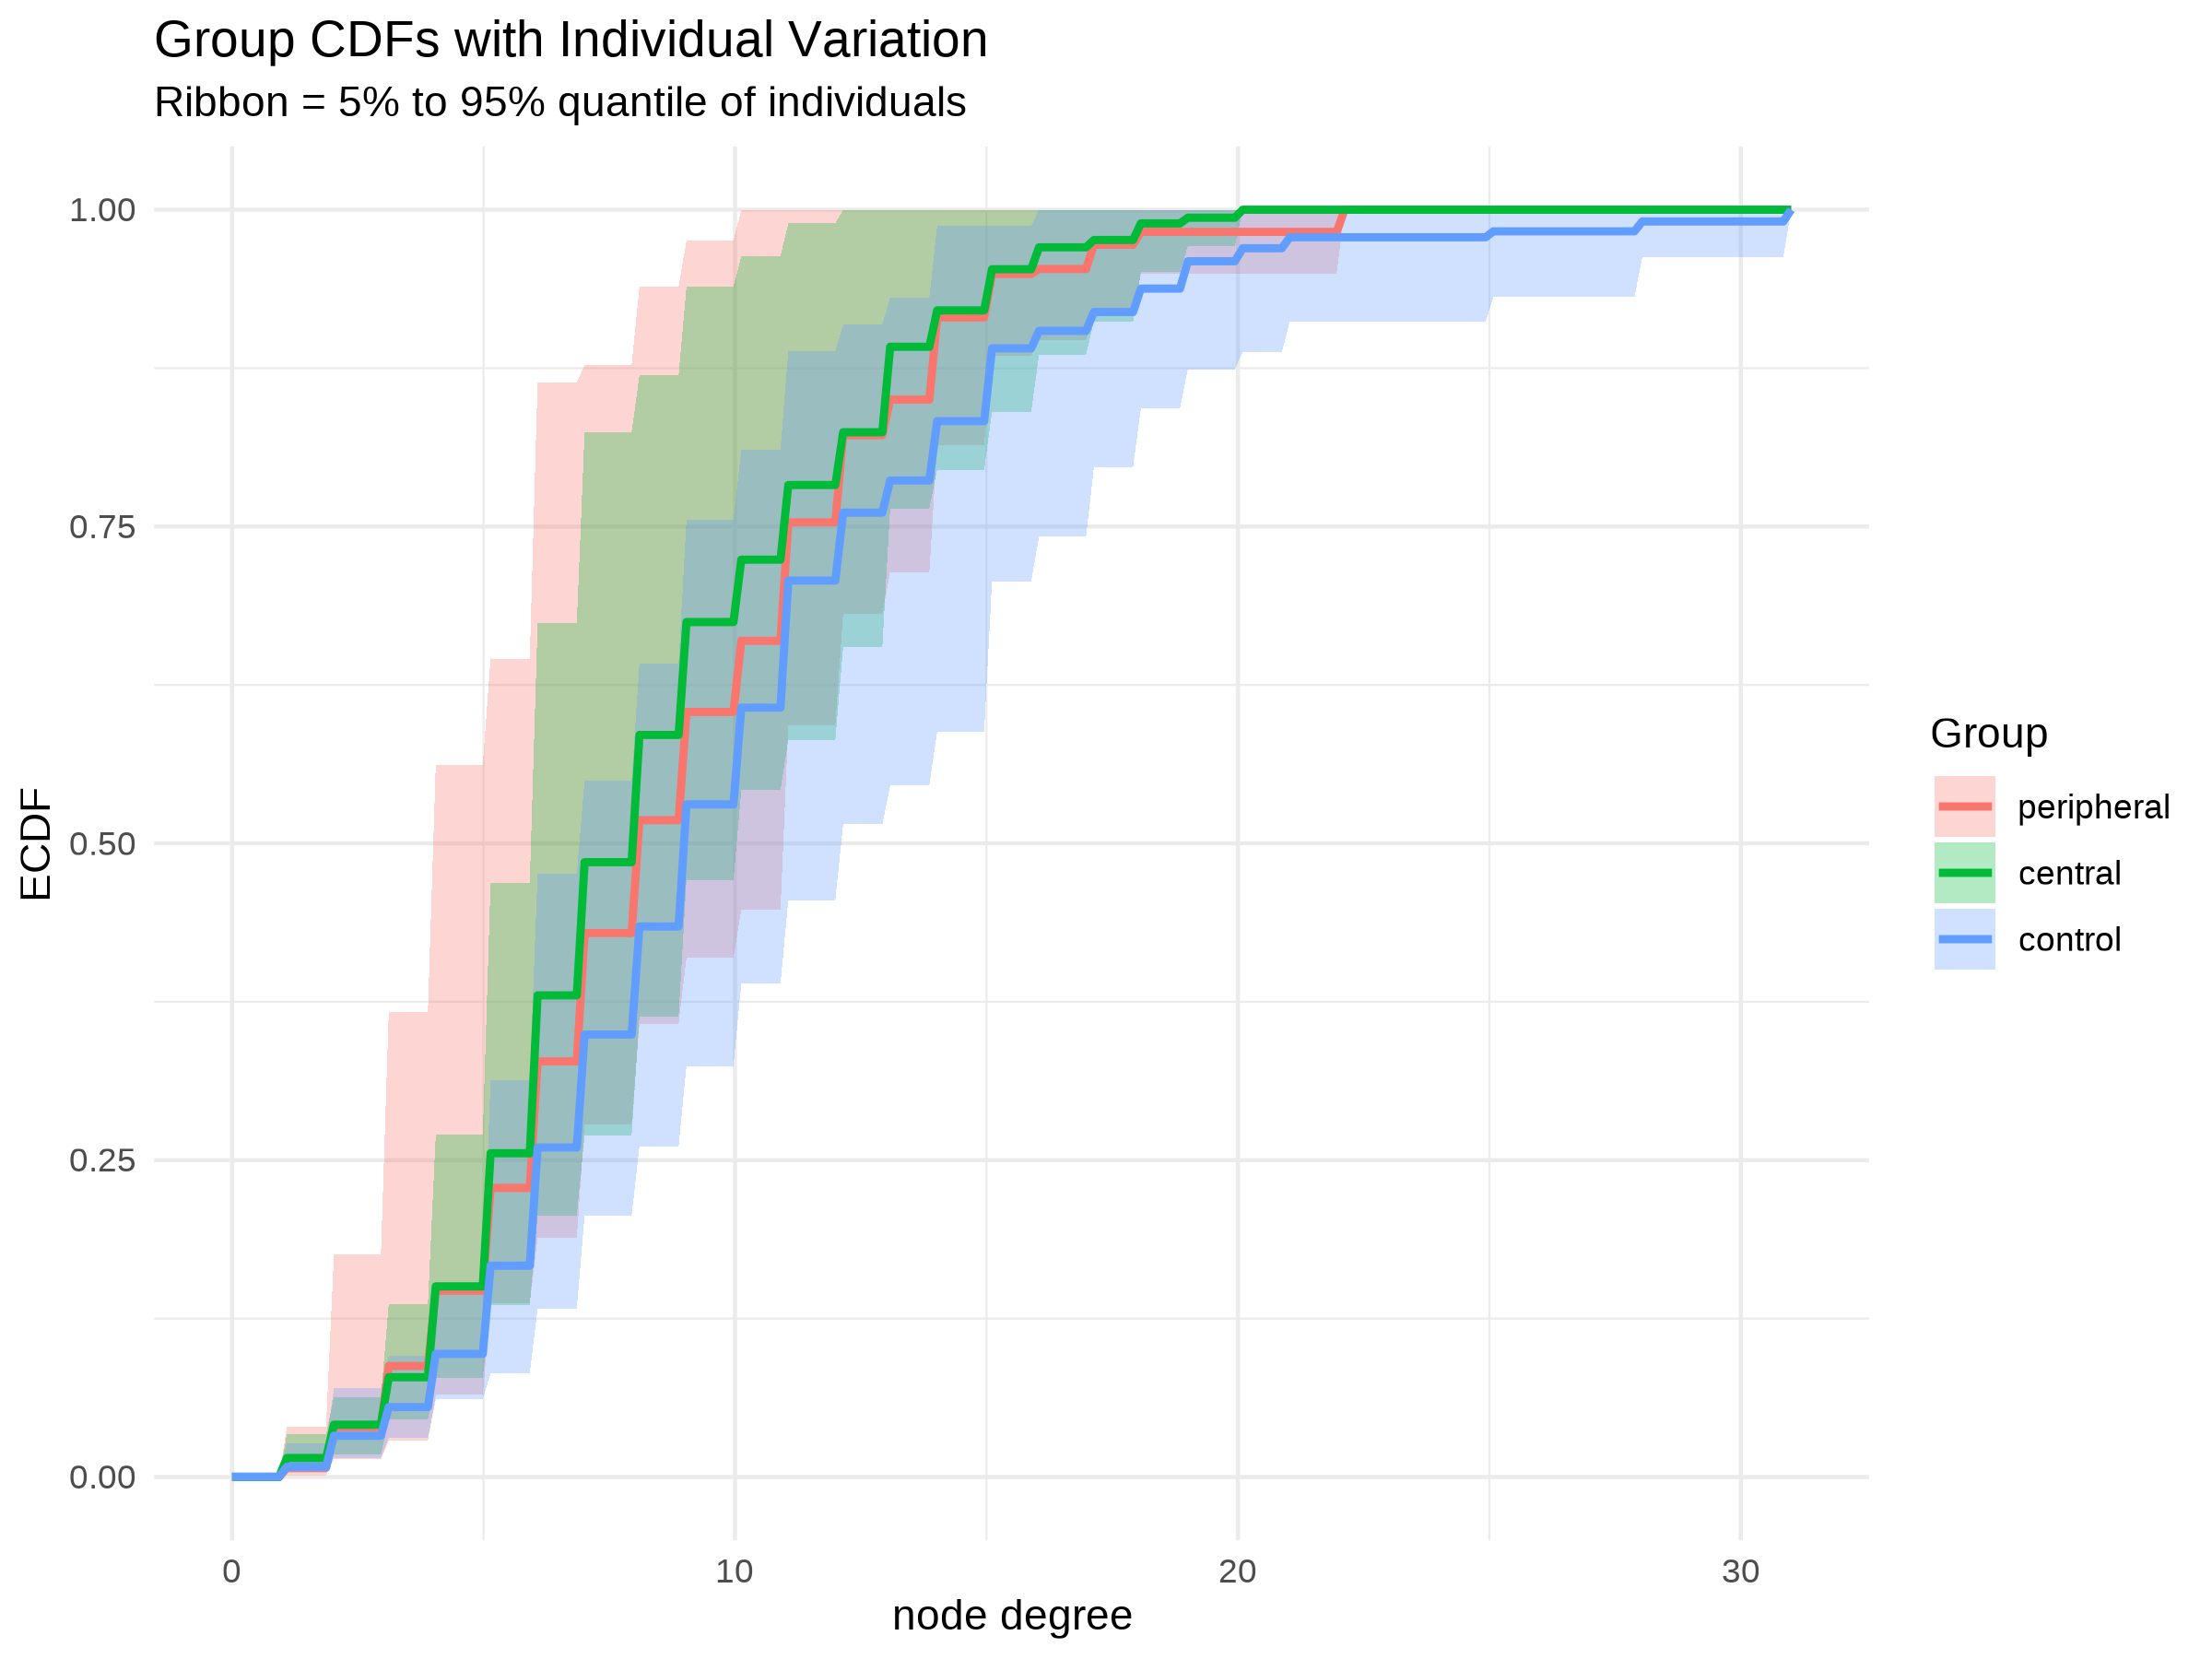

In [24]:
fig <- df_node |> plot_group_cdf_with_ribbon(connections, PID, group)
fig
# ggsave("group_node_degree_ecdf.svg", fig, width = 6, height = 6, units = "in", dpi = 300)

In [25]:
df_node |>
  ggplot(aes(x = clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0,1)+
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")

ERROR while rich displaying an object: Error in `geom_density()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'clusterDuration' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.nul

ERROR: Error in file(con, "rb"): cannot open the connection


plot without title

In [ ]:
df <- read_csv("graph_group_connections.csv")
df <- df |> 
    mutate(
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control")),
        hitObjectColliderName = factor(hitObjectColliderName)
    ) |>
    rename(
        group = category
    )

Rows: 1826 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (2): PID, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
fig <- df |>
  ggplot(aes(x = connections, group = group, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  theme_minimal() +
  labs(title = "Node degree centrality distribution",
       x = "node degree",
       y = "density")
#ggsave("sim_node_degree_dist.svg", fig)
fig

df_node |>
    group_by(PID, building, group, building_location, connections) |>
    ungroup() |>
    filter(connections > 10) |>
    ggplot(aes(x = duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot (node-degree > 10)",
           x = "median cluster duration for each building (s)",
           y = "density")
ggsave("naisu_only_location_node_filter.svg", fig)

Saving 6.67 x 6.67 in image


In [ ]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group * building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [ ]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,4.350301,0.1925744,Inf,3.972862,4.727740
2,inside,6.887977,0.4680248,Inf,5.970666,7.805289


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

In [ ]:
model
library(car)
Anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: connections ~ group * building_location + (1 | PID)
   Data: df_rm_null
      AIC       BIC    logLik  deviance  df.resid 
 9238.169  9282.248 -4611.084  9222.169      1818 
Random effects:
 Groups   Name        Std.Dev.
 PID      (Intercept) 0.02747 
 Residual             0.57017 
Number of obs: 1826, groups:  PID, 24
Fixed Effects:
                         (Intercept)                          groupcentral  
                            0.237722                              0.003478  
                        groupcontrol               building_locationinside  
                           -0.024330                             -0.072348  
groupcentral:building_locationinside  groupcontrol:building_locationinside  
                           -0.017550                             -0.016438  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
group,2.619834,2,2.698424e-01
building_location,310.818873,1,1.448236e-69
group:building_location,2.724093,2,2.561361e-01


#### EMM Node and Dwell Time

In [22]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        duration = clusterDuration
    ) |>
    group_by(PID, group, hitObjectColliderName, building_location) |>
    summarize(
        mean_connections = mean(connections)
    ) |>
    ungroup() |>
    filter(mean_connections > 0)

Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'PID', 'group', 'hitObjectColliderName'.
You can override using the `.groups` argument.


In [23]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, c("control", "peripheral", "central"))
    )

In [24]:
model_0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
model_inter <- glmer(median_clusterDuration ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
df <- df %>% 
    mutate(
        group = factor(group, c("control", "peripheral", "central"))
    )
model_full <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))

In [25]:
node_model_0 <- glmer(mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
node_model_inter <- glmer(mean_connections ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())

node_model_full <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
     

In [26]:
# Create a reference grid
ref_grid <- ref_grid(model_full)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_building <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(model_full, ~ group)
emm_building_eff <- emmeans(model_full, ~ building_location)

VarCorr(model_full)
full_var <- as_tibble(VarCorr(model_full)) %>% pull(sdcor)
full_sd <- sqrt(sum(full_var^2))
eff_size(emm_eff, sigma = full_sd, edf = 1822)

# View results
summary(emm, level = 0.95)
emm_table_pairs <- pairs(emm, adjust = "tukey") %>% summary()

summary(emm_building)
pairs(emm_building, adjust = "tukey")
r2_nakagawa(model_full)

 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.28454 
 PID                   (Intercept) 0.12020 
 Residual                          0.36876 

 contrast             effect.size    SE  df asymp.LCL asymp.UCL
 control - peripheral       0.623 0.198 Inf     0.234   1.01144
 control - central         -0.390 0.195 Inf    -0.771  -0.00782
 peripheral - central      -1.012 0.197 Inf    -1.399  -0.62566

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.481 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,control,0.4331712,0.01687345,Inf,0.4000999,0.4662426
2,peripheral,0.4982853,0.02314907,Inf,0.4529139,0.5436566
3,central,0.4004901,0.01403756,Inf,0.3729770,0.4280032


,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4089780,0.01269419,Inf,0.3840978,0.4338581
2,inside,0.4789864,0.02165684,Inf,0.4365398,0.5214330


 contrast         estimate     SE  df z.ratio p.value
 outside - inside    -0.07 0.0207 Inf  -3.376  0.0007

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

In [30]:
library(performance)
library(MASS)
library(patchwork)
library(ggprism)


Attaching package: ‘patchwork’


The following object is masked from ‘package:MASS’:

    area




In [31]:
df <- df %>% 
    mutate(
        group = factor(group, c("central", "control", "peripheral"))
    )
model_full_emm <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))


ref_grid_emm <- ref_grid(model_full_emm)
custom_emm_table <- emm_table_pairs %>%
    rename(p = p.value) %>%
    mutate(
        group1 = c("control", "control", "peripheral"),
        group2 = c("peripheral", "central", "central"),
        label = c("**", "P = 0.11", "***"),
        y.position = c(0.80, 0.75, 0.85)
    )


dwell_time_fig <- ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = median_clusterDuration, x = group, color = group), alpha = 0.2, data = df)+ 
  labs(
    title = "EMM(s) of Dwell Time",
    x = "Group",
    y = "Dwell Time (s)",
  ) +
  add_pvalue(custom_emm_table, tip.length = 0) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0,1), expand = c(0,0)) 


In [23]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, c("central", "control", "peripheral"))
    )
node_model_full_emm <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = Gamma(link = "inverse"))

In [ ]:
node_ref_grid_emm <- ref_grid(node_model_full_emm)
ndc_mean_fig <- node_ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = mean_connections, x = group, color = group), alpha = 0.2, data = df_node)+ 
  labs(
    title = "EMM(s) of NDC",
    x = "Group",
    y = "NDC"
  ) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0, 20), expand = c(0,0))

In [24]:
# Create a reference grid
ref_grid <- ref_grid(node_model_full_emm)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_eff <- emmeans(node_model_full_emm, ~ group)
eff_size(emm_eff, sigma = sigma(node_model_full_emm)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)


 contrast             effect.size     SE  df asymp.LCL asymp.UCL
 central - control         0.0438 0.0385 Inf   -0.0317   0.11936
 central - peripheral     -0.0233 0.0378 Inf   -0.0973   0.05077
 control - peripheral     -0.0671 0.0385 Inf   -0.1426   0.00849

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.6216 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,central,3.836439,0.4727036,Inf,2.909957,4.762921
2,control,4.371498,0.6515589,Inf,3.094466,5.648530
3,peripheral,3.606621,0.4098208,Inf,2.803387,4.409855


 contrast             estimate    SE  df z.ratio p.value
 central - control      -0.535 0.504 Inf  -1.062  0.5375
 central - peripheral    0.230 0.379 Inf   0.607  0.8163
 control - peripheral    0.765 0.502 Inf   1.523  0.2801

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

In [25]:
# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(node_model_full_emm, ~ building_location)
eff_size(emm_eff, sigma = sigma(node_model_full_emm)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)

 contrast         effect.size     SE  df asymp.LCL asymp.UCL
 outside - inside       0.393 0.0515 Inf     0.292     0.494

Results are averaged over the levels of: group 
sigma used for effect sizes: 0.6216 
Confidence level used: 0.95 

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,2.347044,0.1181907,Inf,2.115394,2.578693
2,inside,5.529328,0.8636406,Inf,3.836624,7.222033


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -3.18 0.849 Inf  -3.749  0.0002

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


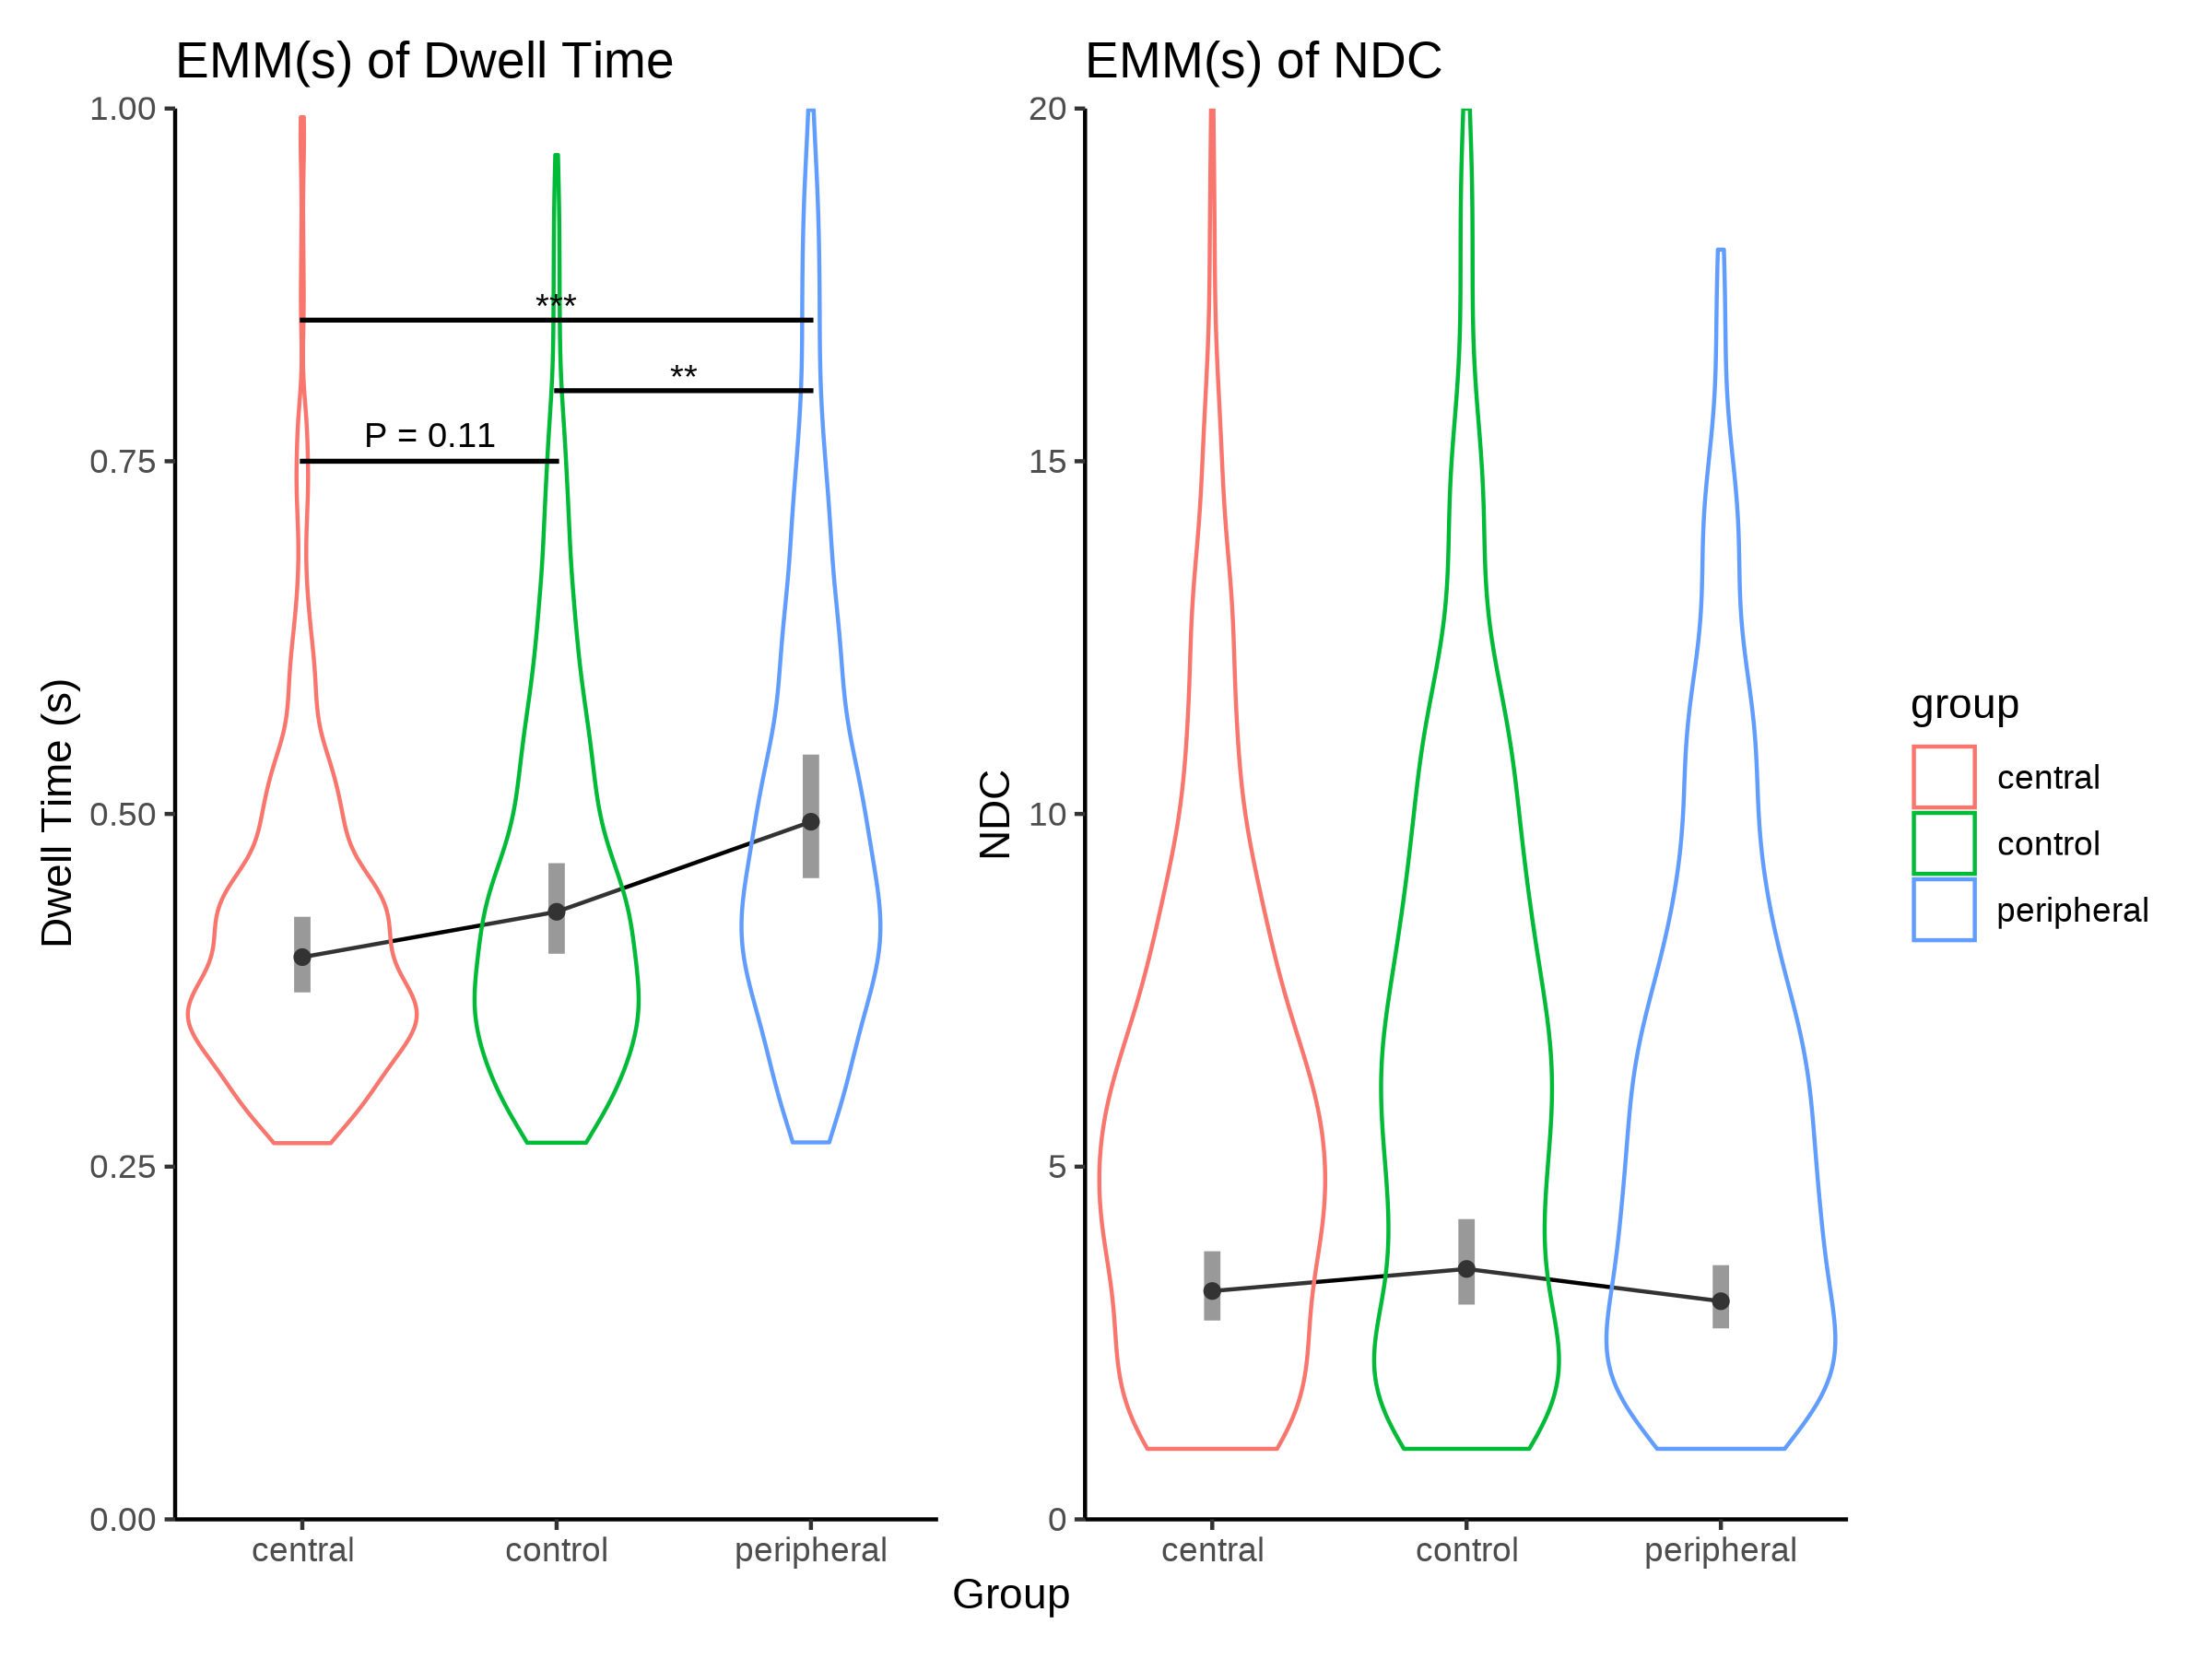

In [ ]:

(dwell_time_fig + ndc_mean_fig + plot_layout(guides = 'collect', axis_titles = 'collect')) & (theme_classic() + theme(legend.position = "none"))

In [ ]:
anova(model_0, model_inter)
anova(model_inter, model_full)
anova(node_model_0, node_model_inter)
anova(node_model_inter, node_model_full)